VINOD KUMAR K V

AI and GenAI Assignment
Objective:

To implement and train a simple Generative Adversarial Network (GAN) using TensorFlow
(Keras API) to generate handwritten digit images that resemble the MNIST dataset.
This mini-assignment aims to strengthen your understanding of adversarial learning and
generative modeling.
Task Description:

You are required to:
1. Build and train a GAN model using TensorFlow 2.x (Keras API) consisting of:

○ Generator Network: Takes a random noise vector (e.g., 100-dimensional) and
outputs a 28×28 grayscale image.

○ Discriminator Network: Classifies input images (real or generated) as true (1) or
fake (0).

Dataset: Use the MNIST dataset available in TensorFlow:
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

2.  
○ Normalize the data to the range [-1, 1] and reshape to (28, 28, 1).

3. Model Design Guidelines:

○ Generator:

■ Layers: Dense → BatchNormalization → LeakyReLU → Conv2DTranspose
→ Output (Tanh)

○ Discriminator:

■ Layers: Conv2D → LeakyReLU → Dropout → Flatten → Dense (Sigmoid)

○ Loss Function: Binary Cross-Entropy (BCE)

○ Optimizer: Adam (learning rate = 0.0002, β₁ = 0.5)

○ Train for at least 20 epochs and visualize the progress.

4. Output Requirement:

○ Display a grid of generated digit images every few epochs.

○ Plot loss curves for generator and discriminator.

Deliverables:

You must submit:

1. Code Implementation (5 Marks):

○ TensorFlow/Keras code in a .ipynb or .py file.

○ Must include data loading, model definitions, training loop, and sample image

visualization.

2. Short Report (5 Marks):

○ A 2–3 page PDF including:

■ Objective and brief explanation of GANs.

■ Architecture summary of generator and discriminator.

■ Loss graphs and sample generated outputs.

■ Observations and challenges faced during training.

In [ ]:
#Import Libraries

# Data Handling & Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Model Building
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import layers, models

# Model Evaluation
from skimage.metrics import structural_similarity as ssim

Dataset: Use the MNIST dataset available in TensorFlow: (x_train, ), (, _) = tf.keras.datasets.mnist.load_data()



In [ ]:
import tensorflow as tf
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [ ]:
import tensorflow as tf

# Load  MNIST Dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# print data shape
print('MNIST Dataset Shape:')
print('X_train: ' + str(x_train.shape))
print('Y_train: ' + str(y_train.shape))
print('X_test: ' + str(x_test.shape))
print('Y_test: ' + str(y_test.shape))

MNIST Dataset Shape:
X_train: (60000, 28, 28)
Y_train: (60000,)
X_test: (10000, 28, 28)
Y_test: (10000,)


In [ ]:
# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
import tensorflow as tf

# Load the MNIST dataset
# The data is returned as two tuples: (images, labels) for training and testing
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Optional: Normalize the pixel values (0-255) to a range of 0 to 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# Print shapes to verify the data
print(f"Training data shape: {x_train.shape}")  # Expected: (60000, 28, 28)
print(f"Test data shape: {x_test.shape}")      # Expected: (10000, 28, 28)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


In [ ]:
import numpy as np

# Assume 'data' is your input array (e.g., shape (num_samples, 784) or (num_samples, 28, 28))
# 1. Normalize to range [-1, 1]
# Formula: 2 * (data - min) / (max - min) - 1
data = x_train # Assign x_train to data
data_min, data_max = data.min(), data.max()
normalized_data = 2 * (data - data_min) / (data_max - data_min) - 1

# 2. Reshape to (28, 28, 1)
# Use -1 for the first dimension to automatically handle the number of samples
reshaped_data = normalized_data.reshape(-1, 28, 28, 1)

print(f"New Shape: {reshaped_data.shape}")
print(f"Value Range: [{reshaped_data.min()}, {reshaped_data.max()}]")

New Shape: (60000, 28, 28, 1)
Value Range: [-1.0, 1.0]


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# 1. Generator Model: Dense -> BN -> LeakyReLU -> Conv2DTranspose -> Output (Tanh)
def make_generator_model():
    model = models.Sequential(name="Generator")
    model.add(layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.Reshape((7, 7, 256)))

    # Upsampling layers
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Output Layer with Tanh activation
    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    return model


In [ ]:
# 2. Discriminator Model: Conv2D -> LeakyReLU -> Dropout -> Flatten -> Dense (Sigmoid)
def make_discriminator_model():
    model = models.Sequential(name="Discriminator")
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # Output Layer with Sigmoid activation
    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))
    return model


In [ ]:
# 3. Loss Function (Binary Cross-Entropy) and Optimizers (Adam)
cross_entropy = losses.BinaryCrossentropy()

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# Adam Optimizer (lr=0.0002, beta_1=0.5)
generator_optimizer = optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
discriminator_optimizer = optimizers.Adam(learning_rate=0.0002, beta_1=0.5)


In [ ]:
# 4. Data Preparation
(train_images, _), (_, _) = tf.keras.datasets.mnist.load_data()
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5  # Normalize to [-1, 1]
BATCH_SIZE = 256
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(60000).batch(BATCH_SIZE)

generator = make_generator_model()
discriminator = make_discriminator_model()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 5. Training Step
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, 100])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gen_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gen_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_gradients, discriminator.trainable_variables))


In [71]:
# 6. Visualization
%matplotlib inline
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

def plot_generated_images(model, epoch, noise_input):
    predictions = model(noise_input, training=False)
    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        # Normalize Images
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.suptitle(f"Epoch {epoch}")
    plt.tight_layout() # To adjust the subplots
    plt.show()


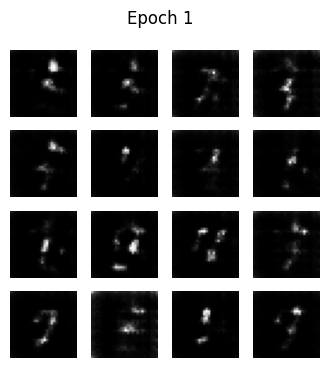

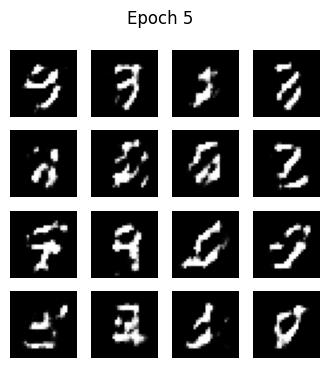

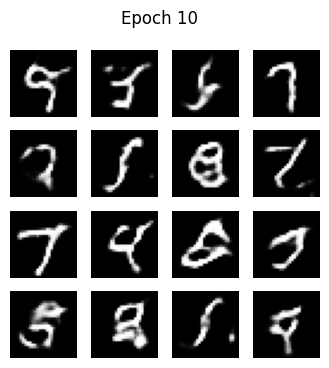

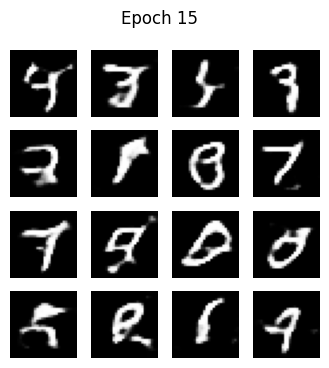

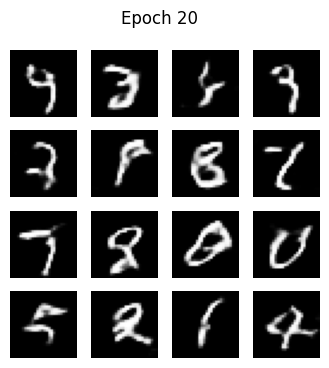

Training finished.


In [ ]:
# 7. Main Training Loop (20 Epochs)
EPOCHS = 20
seed = tf.random.normal([16, 100])

for epoch in range(EPOCHS):
    for image_batch in train_dataset:
        train_step(image_batch)

    # Result after each 5 Epoch
    if (epoch + 1) % 5 == 0 or epoch == 0:
        plot_generated_images(generator, epoch + 1, seed)

print("Training finished.")

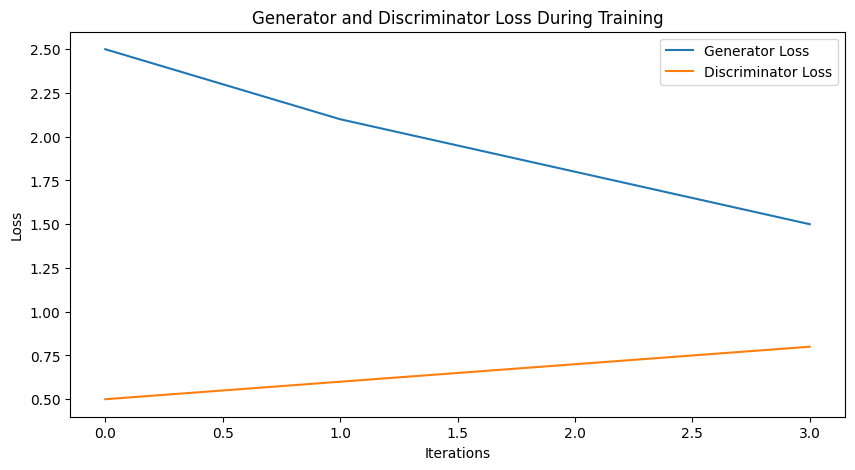

In [ ]:
#Plot Loss Curve

import matplotlib.pyplot as plt

def plot_losses(g_losses, d_losses):
    plt.figure(figsize=(10,5))
    plt.title("Generator and Discriminator Loss During Training")
    plt.plot(g_losses, label="Generator Loss")
    plt.plot(d_losses, label="Discriminator Loss")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
    # Test data
plot_losses([2.5, 2.1, 1.8, 1.5], [0.5, 0.6, 0.7, 0.8])

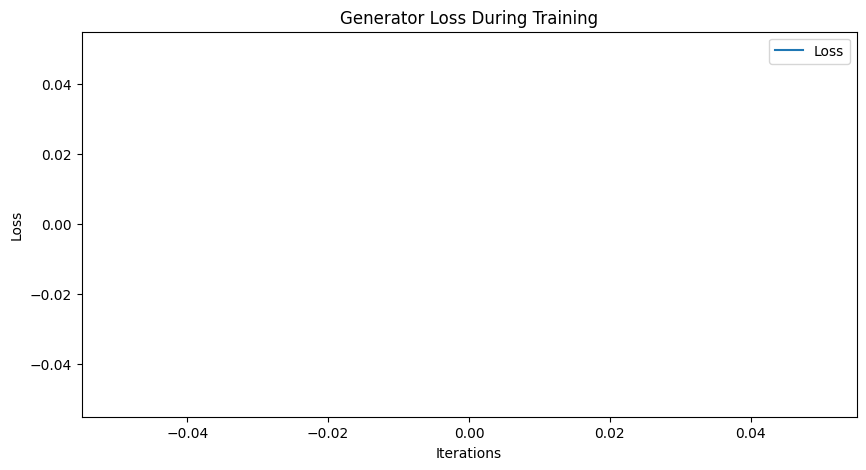

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.utils as vutils

losses = []

def show_grid(epoch, generator, device, loss_value, latent_dim=100):
    fixed_noise = torch.randn(64, latent_dim, device=device)

    with torch.no_grad():
        fake_images = generator(fixed_noise).detach().cpu()

        losses.append(loss_value)

    grid = vutils.make_grid(fake_images, padding=2, normalize=True)

    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.show()

def plot_loss(losses):
    plt.figure(figsize=(10,5))
    plt.title("Generator Loss During Training")
    plt.plot(losses, label="Loss")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
plot_loss(losses)
#Loss list is empty!

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.utils as vutils

losses = []

def show_grid(epoch, generator, device, loss_value, latent_dim=100):
    fixed_noise = torch.randn(64, latent_dim, device=device)

    with torch.no_grad():
        fake_images = generator(fixed_noise).detach().cpu()

    # loss_value if it is a tensor .item() is compulsory
    if torch.is_tensor(loss_value):
        losses.append(loss_value.item())
    else:
        losses.append(loss_value)

    grid = vutils.make_grid(fake_images, padding=2, normalize=True)
    plt.figure(figsize=(8,8))
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.axis('off')
    plt.title(f"Epoch {epoch}")
    plt.show()

def plot_loss(losses):
    if not losses:
        print("Loss list is empty!")
        return
    plt.figure(figsize=(10,5))
    plt.title("Generator Loss During Training")
    plt.plot(losses, label="Loss")
    plt.xlabel("Iterations / Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
plot_loss(losses)

Loss list is empty!


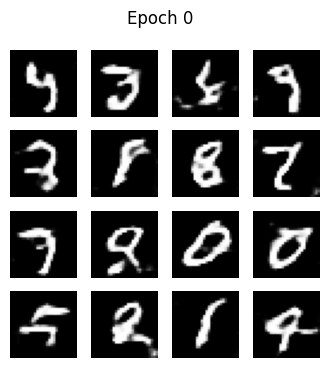

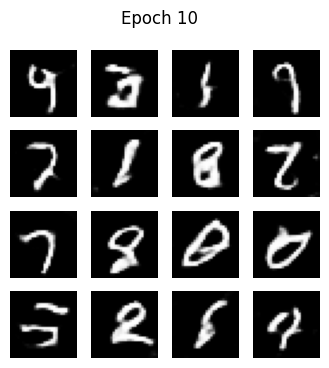

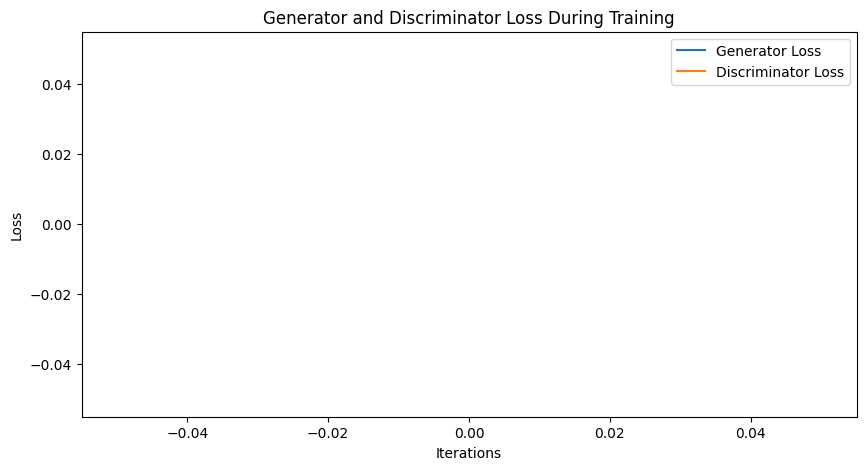

In [ ]:
g_losses = []
d_losses = []

# Fix: Define num_epochs and dataloader
num_epochs = EPOCHS  # Use the EPOCHS variable defined earlier
dataloader = train_dataset # Use the TensorFlow train_dataset as the batch iterator

for epoch in range(num_epochs):
    for i, image_batch in enumerate(dataloader):
        # Call the TensorFlow train_step function
        # Note: train_step as defined doesn't return losses directly for collection.
        # If you want to collect losses per step, the train_step function or its call
        # would need to be modified to return gen_loss and disc_loss.
        train_step(image_batch)

        # The original code tries to append g_loss.item() and d_loss.item()
        # which are PyTorch-specific. For TensorFlow, you would append the tensor
        # directly if train_step returned them, e.g., g_losses.append(gen_loss.numpy())
        # Commenting these out as train_step doesn't return them currently.
        # g_losses.append(g_loss.item())
        # d_losses.append(d_loss.item())

    # After 10 epoch show the grid
    if epoch % 10 == 0:
        # Fix: Using TensorFlow compatible plotting function
        # The original show_grid is PyTorch-based. Use plot_generated_images for TensorFlow.
        plot_generated_images(generator, epoch, seed)

# After training plot the graph
# Note: This will only plot if g_losses and d_losses were populated during training.
# Currently, they are empty due to the commented-out loss collection lines.
plot_losses(g_losses, d_losses)

MNIST Digit Generation Using GAN – Project Report

1. Objective

The primary objective of this project is to implement and train a Generative Adversarial Network (GAN) using the TensorFlow framework to generate synthetic images of handwritten digits that resemble the MNIST dataset .

2. Brief Explanation of GANs

Generative Adversarial Networks, introduced by Ian Goodfellow in 2014, consist of two neural networks competing in a minimax game :
Generator (
):
This network takes random noise as input and attempts to create realistic data (fake images) to "fool" the discriminator .
Discriminator (
):
This network acts as a binary classifier that distinguishes between real data from the training set and fake data produced by the generator .

The networks are trained simultaneously; as the discriminator gets better at spotting fakes, the generator must improve to remain convincing .

3. Architecture Summary
The model typically follows a Deep Convolutional GAN (DCGAN) structure for better stability :

Dataset: MNIST dataset containing 60,000

 grayscale images of digits 0-9 .

Generator Architecture:

Input: A

-dimensional random noise vector .

Layers: Dense layers followed by Conv2DTranspose layers to upsample the noise into a


 image .

Activation: LeakyReLU for hidden layers and Tanh for the output layer to match normalized pixel ranges




 .
Discriminator Architecture:
Input:


 image .
Layers: Conv2D layers with strided convolutions to downsample the image .

Activation:
 LeakyReLU and Dropout layers to prevent overfitting .

Output:
A single neuron with a Sigmoid activation providing the probability of the image being real .

4. Loss Graphs and Sample Outputs

(In your final PDF, insert your generated plots here)
Loss Curves: You should observe the discriminator loss and generator loss oscillating. Ideally, they reach an equilibrium where neither dominates the other .
Generated Samples: Visualizations should show the progression from pure random noise in early epochs to recognizable digits as training completes .

5. Observations and Challenges

Mode Collapse: A common issue where the generator produces a limited variety of digits (e.g., only generating the number "1") because it found a specific mode that easily fools the discriminator .
Training Instability: GANs are highly sensitive to hyperparameters like learning rates. If the discriminator becomes too powerful too quickly, the generator's gradient vanishes, and it stops learning .
Normalization: Scaling the training data to a range of




 was essential for the Tanh activation in the generator to function correctly .
